In [1]:
import pandas as pd
import numpy as np

# открываем .pkl файл
df = pd.read_pickle('data.pkl')

print(df.shape)
df

(38976, 57)


,name,description,neighborhood_overview,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_neighbourhood,...,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,host_verifications_email,host_verifications_phone,host_verifications_work_email,host_age_on_platform
1,"Marais - Charming loft, river view","In the heart of historical Paris le Marais, gr...",Le Marais is the heart of Paris. Few years ago...,"Paris, France","I travel a lot for work and when I'm away, my ...",3,1.00,0.92,True,Saint-Paul - Ile Saint-Louis,...,False,1,1,0,0,0.66,True,True,False,11.446575
3,"Cozy place, Sacré Coeur Montmartre in the SoPi",Cozy apartment close to everything.<br />Perfe...,One of the most trendy corners of the capital ...,"Paris, France","Jeune ingénieur, je propose mon appartement à ...",1,1.00,0.89,False,Pigalle - Saint-Georges,...,False,1,1,0,0,0.72,True,True,False,12.172603
5,Prestige on the Louvre & Tuileries,Experience luxury on the 6th floor with elevat...,"With a setting right in the heart of Paris, ma...","Paris, France","Passionné d'art et styliste de profession, je ...",1,1.00,0.98,True,Louvre - Tuileries,...,False,1,1,0,0,2.71,True,True,False,11.482192
7,COSY & STYLE - PARIS SAINT MARTIN -,"In the heart of Paris, this 40 m² apartment is...",Discovering the 10th arrondissement of Paris<b...,"Paris, France",Nous serons à votre écoute pour toutes informa...,3,1.00,0.50,False,Canal Saint-Martin,...,False,1,1,0,0,0.99,True,True,False,11.441096
8,Atelier St. Germain,NaN,"The elegant 7th is rich with art and culture, ...","Paris, France",Like travailling and know difference cultures ...,1,1.00,0.70,True,Champs-Elysées,...,False,6,6,0,0,0.81,True,True,False,13.783562
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81845,Appartement ensoleillé au cœur de Paris Bellev...,Our 52 m² apartment is located on a quiet stre...,NaN,"Fleury-les-Aubrais, France","Bonjour,\nNous sommes parents de 3 jeunes fill...",3,0.80,0.63,True,Alésia,...,True,2,2,0,0,NaN,True,True,False,11.569863
81846,Apt a/c 3BR/6P - Saint-Lazare/Les Champs Elysée,📌 Checkmyguest offers you a charming and spaci...,🏘️ The 8th arrondissement of Paris is one of t...,"Paris, France",Checkmyguest est une entreprise de gestion loc...,1,1.00,1.00,True,NaN,...,True,184,184,0,0,NaN,True,True,False,2.186301
81848,Apt a/c 1BR/2P - Saint-Lazare/Les Champs Elysée,📌 Checkmyguest offers you a charming and spaci...,🏘️ The 8th arrondissement of Paris is one of t...,"Paris, France",Checkmyguest est une entreprise de gestion loc...,1,1.00,1.00,True,NaN,...,True,184,184,0,0,2.00,True,True,False,2.186301
81850,Cozy studio - 2P - Place des Vosges/Marais,Checkmyguest offers you an exceptional 24 m² s...,"Romantic, festive and trendy, the Marais distr...",NaN,NaN,1,0.99,1.00,False,NaN,...,True,3,3,0,0,1.00,True,True,False,0.397260


Перекодируем признаки, которые нам понадобятся в будущем для кластеризации:

In [2]:
if 'amenities' in df.columns:
    # превращаем все найденные слова в их количество
    def count_amenities(x):
        if pd.isna(x):
            return 0
        if isinstance(x, list):
            return len(x)
        if isinstance(x, str):
            x = x.strip('{}').replace('"', '')
            return len([i for i in x.split(',') if i.strip()])
        return 0
    
    df['amenities_count'] = df['amenities'].apply(count_amenities)
    print(f"amenities_count: создано, среднее = {df['amenities_count'].mean():.1f}")

amenities_count: создано, среднее = 28.2


In [3]:
if 'bathrooms_text' in df.columns:
    # извлекаем число из этого признака
    def extract_bathrooms(text):
        if pd.isna(text):
            return np.nan
        import re
        match = re.search(r'(\d+\.?\d*)', str(text))
        if match:
            return float(match.group(1))
        if 'half' in str(text).lower():
            return 0.5
        return np.nan
    
    df['bathrooms'] = df['bathrooms_text'].apply(extract_bathrooms)
    # заполняем пропуски медианой
    df['bathrooms'] = df['bathrooms'].fillna(df['bathrooms'].median())
    print(f"bathrooms: извлечено из текста, пропусков после заполнения: {df['bathrooms'].isna().sum()}")

bathrooms: извлечено из текста, пропусков после заполнения: 0


In [4]:
if 'bedrooms' in df.columns:
    # студии (accommodates <= 2, property_type = 'Apartment') могут иметь 0 спален
    # заполняем пропуски медианой по типу объекта
    median_by_type = df.groupby('property_type')['bedrooms'].median()
    df['bedrooms_filled'] = df.apply(
        lambda row: median_by_type[row['property_type']] 
        if pd.isna(row['bedrooms']) and row['property_type'] in median_by_type 
        else row['bedrooms'],
        axis=1
    )
    df['bedrooms'] = df['bedrooms'].fillna(df['bedrooms'].median())
    print(f"bedrooms: заполнено {df['bedrooms'].isna().sum()} пропусков медианой")

bedrooms: заполнено 0 пропусков медианой


In [5]:
df['has_reviews'] = df['first_review'].notna().astype(int)

In [6]:
review_columns = [
    'first_review', 'last_review', 'review_scores_rating',
    'review_scores_accuracy', 'review_scores_cleanliness',
    'review_scores_checkin', 'review_scores_communication',
    'review_scores_location', 'review_scores_value', 'reviews_per_month'
]

# для колонок с отзывами: NaN заменяем на 0 (нет отзывов - 0 баллов)
for col in review_columns:
    if col in df.columns:
        df[col] = df[col].fillna(0)
        print(f"{col}: заполнено NaN → 0")

first_review: заполнено NaN → 0
last_review: заполнено NaN → 0
review_scores_rating: заполнено NaN → 0
review_scores_accuracy: заполнено NaN → 0
review_scores_cleanliness: заполнено NaN → 0
review_scores_checkin: заполнено NaN → 0
review_scores_communication: заполнено NaN → 0
review_scores_location: заполнено NaN → 0
review_scores_value: заполнено NaN → 0
reviews_per_month: заполнено NaN → 0


Для решения задачи кластеризации для начала нужно сократить число признаков. Для этого возьмём только главные признаки объекта по каждой из категорий:

1. физические характеристики объекта
    - accomodates - вместимость
    - bathrooms - количество ванных комнат
    - bedrooms - количество спален
    - amenities_count - количество удобств (показатель элитности объекта)
2. расположение и доступность
    - latitude + longtitude - расположение объекта, координаты
    - availability_30
3. популярность и доверие
   - number_of_reviews
   - review_scores_rating
   - has_reviews
   - reviews_per_month
4. хозяин объекта
   - host_is_superhost
   - host_response_rate
   - host_age_on_platform
5. правила и тип
   - room_type
   - property_type
   - instant_bookable

In [7]:
final_features = [
    'accommodates',
    'bedrooms', 
    'bathrooms',
    'amenities_count',
    
    'latitude',
    'longitude',
    'availability_30',
    
    'number_of_reviews',
    'review_scores_rating',
    'has_reviews',
    'reviews_per_month',
    
    'host_is_superhost',
    'host_response_rate',
    'host_age_on_platform',
    
    'room_type',
    'property_type',
    'instant_bookable'
]

missing_cols = [col for col in final_features if col not in df.columns]
if missing_cols:
    print(f"Предупреждение: нет колонок {missing_cols}")
    final_features = [col for col in final_features if col in df.columns]

# создаем финальную таблицу
df_cluster = df[final_features].copy()
print(f"Финальная таблица: {df_cluster.shape}")
print(f"Колонок: {len(df_cluster.columns)}")
print(f"\nСписок колонок:\n{df_cluster.columns.tolist()}")

Финальная таблица: (38976, 17)
Колонок: 17

Список колонок:
['accommodates', 'bedrooms', 'bathrooms', 'amenities_count', 'latitude', 'longitude', 'availability_30', 'number_of_reviews', 'review_scores_rating', 'has_reviews', 'reviews_per_month', 'host_is_superhost', 'host_response_rate', 'host_age_on_platform', 'room_type', 'property_type', 'instant_bookable']


Переделаем room type из категориальных в числовые, используя one-hot encoding

In [8]:
df_cluster = pd.get_dummies(df_cluster, columns=['room_type'], drop_first=True)

print(f"После one-hot кодирования: {df_cluster.shape}")

После one-hot кодирования: (38976, 19)


Для property type используем частотное кодирование, так как там вариантов слишком много для one-hot

In [9]:
freq_encoding = df_cluster['property_type'].value_counts(normalize=True).to_dict()
df_cluster['property_frequency'] = df_cluster['property_type'].map(freq_encoding)
df_cluster = df_cluster.drop(columns=['property_type'])

In [10]:
df_cluster

,accommodates,bedrooms,bathrooms,amenities_count,latitude,longitude,availability_30,number_of_reviews,review_scores_rating,has_reviews,reviews_per_month,host_is_superhost,host_response_rate,host_age_on_platform,instant_bookable,room_type_Hotel room,room_type_Private room,room_type_Shared room,property_frequency
1,2,1.0,1.0,27,48.852030,2.361760,0.100000,88,4.86,1,0.66,True,1.00,11.446575,False,False,False,False,0.820146
3,3,1.0,1.0,32,48.882710,2.343550,0.100000,99,4.81,1,0.72,False,1.00,12.172603,False,False,False,False,0.820146
5,4,1.0,2.0,66,48.863990,2.334230,0.133333,366,4.93,1,2.71,True,1.00,11.482192,False,False,False,False,0.820146
7,3,1.0,1.0,42,48.874910,2.366770,0.400000,137,4.47,1,0.99,False,1.00,11.441096,False,False,False,False,0.820146
8,5,1.0,1.0,42,48.854130,2.325320,0.333333,113,4.82,1,0.81,True,1.00,13.783562,False,False,False,False,0.820146
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81845,2,1.0,1.0,32,48.875029,2.395902,0.233333,0,0.00,0,0.00,True,0.80,11.569863,True,False,False,False,0.820146
81846,6,3.0,2.5,38,48.875271,2.325716,0.700000,0,0.00,0,0.00,True,1.00,2.186301,True,False,False,False,0.820146
81848,2,1.0,1.0,36,48.875271,2.325716,0.366667,2,5.00,1,2.00,True,1.00,2.186301,True,False,False,False,0.820146
81850,2,1.0,1.0,34,48.854545,2.363546,0.133333,1,4.00,1,1.00,False,0.99,0.397260,True,False,False,False,0.820146


Теперь стандартизируем все наши числовые признаки при помощи FunctionTransformer и логарифмической функции (так как использование Standart Scaler ухудшает качество моделей (из-за большого количества выбросов в признаках))

In [11]:
from sklearn.preprocessing import StandardScaler, FunctionTransformer

scaler = FunctionTransformer(np.log1p, validate=True)
X_scaled = scaler.fit_transform(df_cluster)

print(f"\nПосле стандартизации:")
print(f"Среднее каждого признака: {X_scaled.mean(axis=0).round(2)}")
print(f"Стандартное отклонение: {X_scaled.std(axis=0).round(2)}")


После стандартизации:
Среднее каждого признака: [1.41 0.84 0.77 3.21 3.91 1.21 0.33 2.37 1.37 0.55 0.6  0.19 0.51 1.96
 0.23 0.01 0.08 0.   0.5 ]
Стандартное отклонение: [0.37 0.25 0.19 0.65 0.   0.01 0.23 1.71 0.71 0.28 0.55 0.31 0.29 0.65
 0.33 0.06 0.22 0.04 0.22]


Теперь сделаем выборку данных для построения модели

In [12]:
sample_size = 3000
np.random.seed(42)

indices = np.random.choice(len(X_scaled), sample_size, replace=False)
X_sample = X_scaled[indices]
df_sample = df_cluster.iloc[indices].copy()
print(f"\nСделана выборка: {len(X_sample)} объектов из {len(X_scaled)}")


Сделана выборка: 3000 объектов из 38976


Теперь построим иерархическую модель. В качестве метрики будем использовать евклидову, она подходит для стандартизированных данных. Используем  метод ward - он минимизирует дисперсию внутри кластера.

In [13]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.decomposition import PCA

Z = linkage(X_sample, method='ward', metric='euclidean')

Для визуализации воспользуемся дендрограммой:

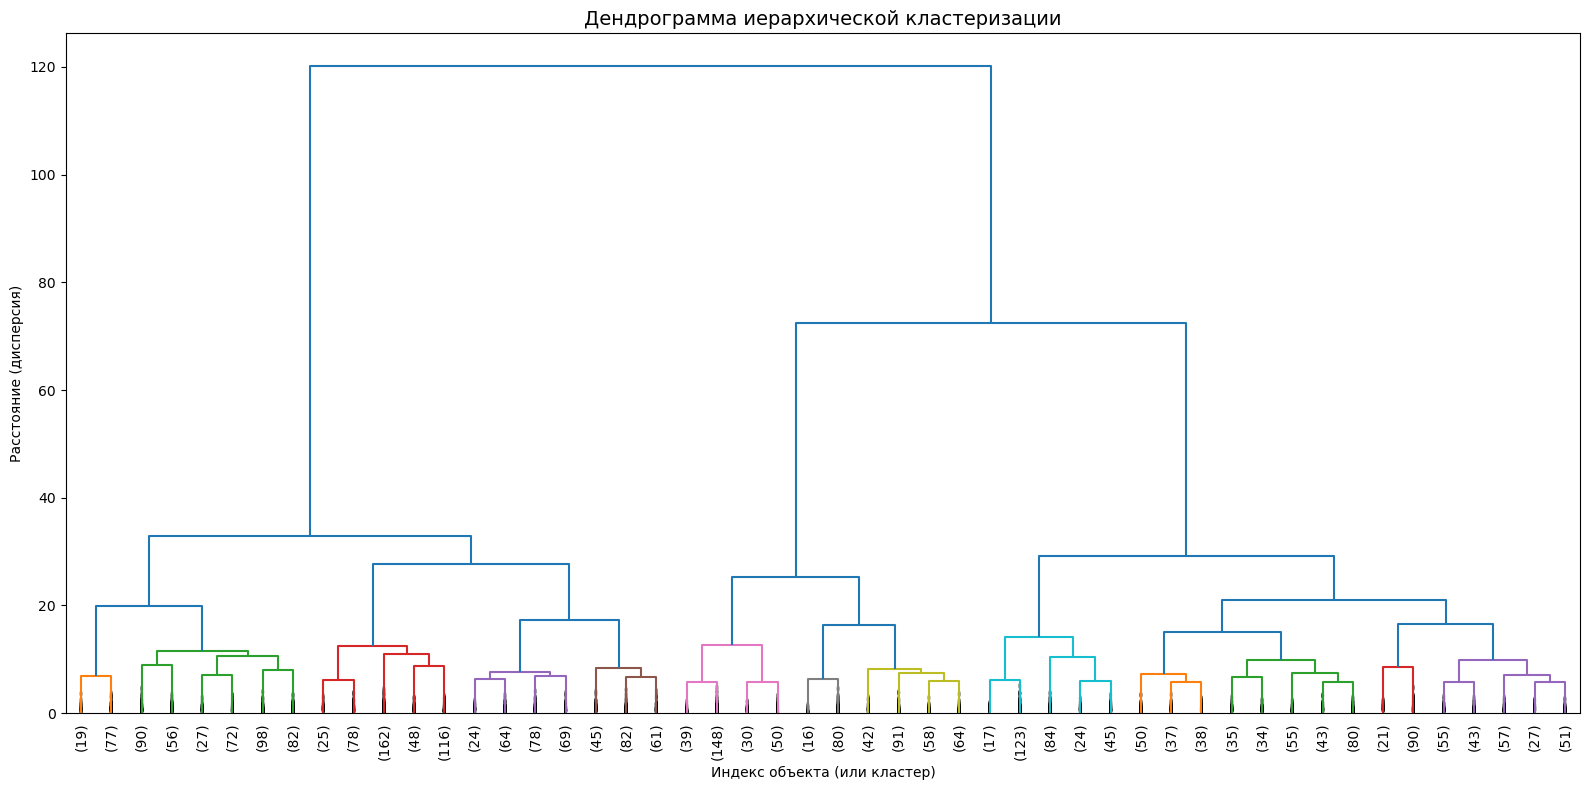

In [14]:
plt.figure(figsize=(16, 8))

dendrogram(Z, 
           truncate_mode='lastp',
           p=50,
           leaf_rotation=90.,
           leaf_font_size=10,
           show_contracted=True,
           color_threshold=15)

plt.title('Дендрограмма иерархической кластеризации', fontsize=14)
plt.xlabel('Индекс объекта (или кластер)')
plt.ylabel('Расстояние (дисперсия)')
plt.tight_layout()
plt.show()

Теперь попробуем посмотреть на метрики качества модели для того чтобы добиться наилучшего результата. В качестве метрик качества модели кластеризации мы будем использовать коэффициет копенетической корреляции и силуэтный коэффициент. Копенетическая корреляция отражает качество самой дендрограммы и насколько хорошо она отображает реальные расстояния между объектами (чем ближе к 1 - тем лучше). Её значение не зависит от числа кластеров. Силуэтный коэффициент считается на основе расстояний объектов между друг другом внутри кластера и расстояний между кластерами и показывает насколько объекты отличаются друг от друга (чем ближе к 1 - тем лучше)


Копенетическая корреляция: 0.6304


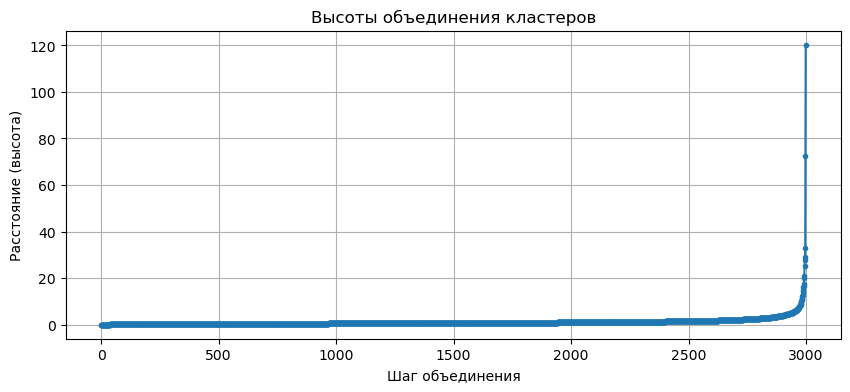


Распределение объектов по кластерам (n_clusters=4):
cluster
1     521
2     852
3     618
4    1009
Name: count, dtype: int64

Силуэтный коэффициент: 0.2165


In [15]:
from scipy.cluster.hierarchy import cophenet
from scipy.spatial.distance import pdist

# коэффициент копенетической корреляции
c, coph_dists = cophenet(Z, pdist(X_sample))
print(f"\nКопенетическая корреляция: {c:.4f}")

# анализ высот объединений
plt.figure(figsize=(10, 4))
plt.plot(Z[:, 2], marker='o', linestyle='-', markersize=3)
plt.title('Высоты объединения кластеров')
plt.xlabel('Шаг объединения')
plt.ylabel('Расстояние (высота)')
plt.grid(True)
plt.show()

n_clusters = 4  

clusters = fcluster(Z, t=n_clusters, criterion='maxclust')

df_sample['cluster'] = clusters

print(f"\nРаспределение объектов по кластерам (n_clusters={n_clusters}):")
print(df_sample['cluster'].value_counts().sort_index())

from sklearn.metrics import silhouette_score

# силуэтный коэффициент
sil_score = silhouette_score(X_sample, clusters)
print(f"\nСилуэтный коэффициент: {sil_score:.4f}")

Для подбора числа кластеров воспользуемся циклом:

Поиск оптимального числа кластеров
k=2: Silhouette = 0.3473
k=3: Silhouette = 0.3157
k=4: Silhouette = 0.2165
k=5: Silhouette = 0.2022
k=6: Silhouette = 0.1994
k=7: Silhouette = 0.1639
k=8: Silhouette = 0.1523
k=9: Silhouette = 0.1472
k=10: Silhouette = 0.1415


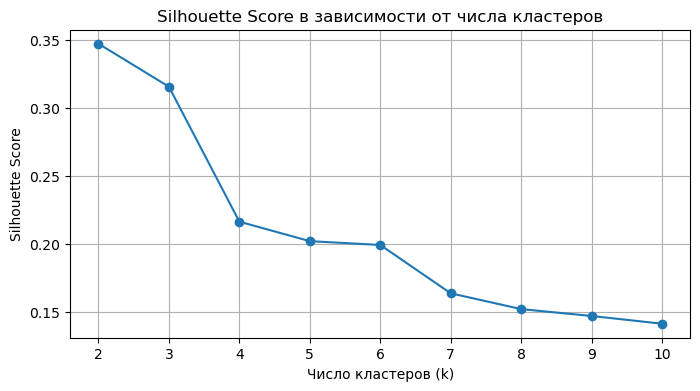


Оптимальное число кластеров по Silhouette: 2


In [16]:
print("Поиск оптимального числа кластеров")

sil_scores = []
for k in range(2, 11):
    labels = fcluster(Z, t=k, criterion='maxclust')
    score = silhouette_score(X_sample, labels)
    sil_scores.append(score)
    print(f"k={k}: Silhouette = {score:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(range(2, 11), sil_scores, marker='o')
plt.title('Silhouette Score в зависимости от числа кластеров')
plt.xlabel('Число кластеров (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

best_k = range(2, 11)[np.argmax(sil_scores)]
print(f"\nОптимальное число кластеров по Silhouette: {best_k}")

Попробуем  воспользоваться PCA визуализацией наших объектов для того чтобы посмотреть, можно ли там визуально выделить какие либо структуры или нет

PC1: 66.32%
PC2: 9.30%


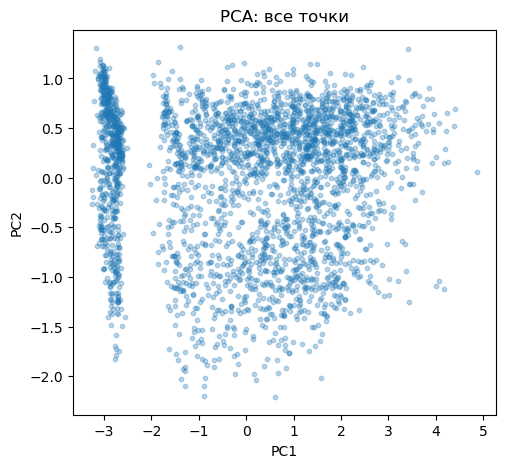

In [17]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sample)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.3, s=10)
plt.title('PCA: все точки')
plt.xlabel('PC1')
plt.ylabel('PC2')

print(f"PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"PC2: {pca.explained_variance_ratio_[1]:.2%}")

Также посмотрим на 3D PCA визуализацию и доли объяснённой дисперсии для каждой компоненты

Размер X_sample: (3000, 19)


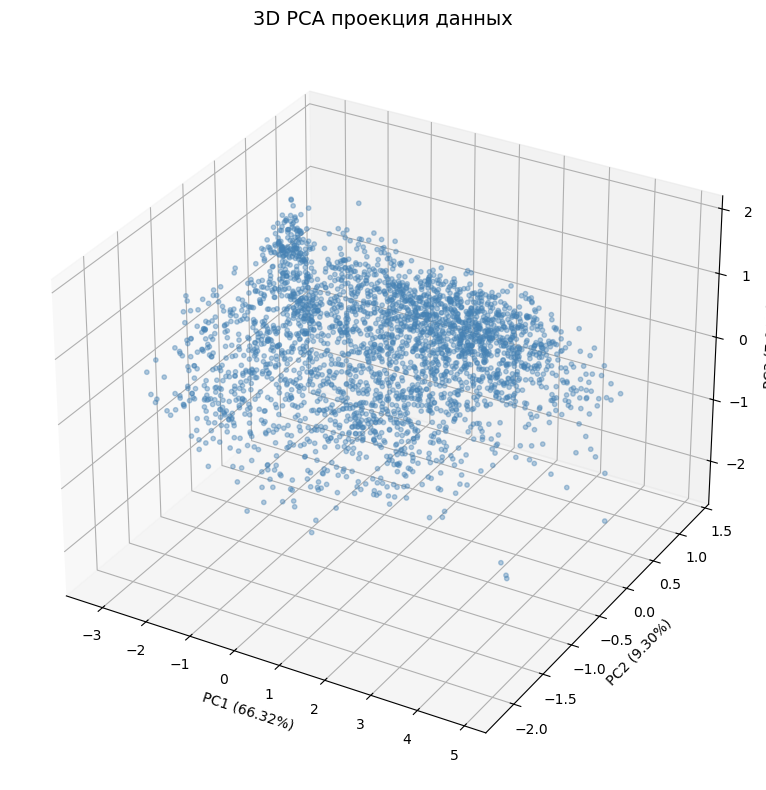

PC1: 66.32%
PC2: 9.30%
PC3: 7.04%
Суммарно: 82.65%


In [18]:
from mpl_toolkits.mplot3d import Axes3D

print(f"Размер X_sample: {X_sample.shape}")

pca3 = PCA(n_components=3)
X_pca3 = pca3.fit_transform(X_sample)
fig_3d = plt.figure(figsize=(12, 8))
ax = fig_3d.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_pca3[:, 0], 
    X_pca3[:, 1], 
    X_pca3[:, 2],
    c='steelblue',
    alpha=0.4,
    s=10
)

ax.set_title('3D PCA проекция данных', fontsize=14)
ax.set_xlabel(f'PC1 ({pca3.explained_variance_ratio_[0]:.2%})', fontsize=10)
ax.set_ylabel(f'PC2 ({pca3.explained_variance_ratio_[1]:.2%})', fontsize=10)
ax.set_zlabel(f'PC3 ({pca3.explained_variance_ratio_[2]:.2%})', fontsize=10)

plt.tight_layout()
plt.show()

print(f"PC1: {pca3.explained_variance_ratio_[0]:.2%}")
print(f"PC2: {pca3.explained_variance_ratio_[1]:.2%}")
print(f"PC3: {pca3.explained_variance_ratio_[2]:.2%}")
print(f"Суммарно: {pca3.explained_variance_ratio_.sum():.2%}")

Как мы можем заметить, какие либо структуры на графиках выделить сложно. Попробуем воспользоваться T-SNE визуализацией объектов для наших многомерных данных. Данная визуализация работает на основе распределения вероятноятностей соседства разных объектов, локальная структура будет максимально сохранена. Также попробуем раскрасить нашу визуализацию по целевой переменной, которая используется в другой задаче (availibility_30), чтобы понять, будет ли какой то бизнес-смысл от нашего деления на кластеры. Если мы сможем обнаружить разные скопления раскрашенные в разные цвета, то это будет успехом. Также посмотрим насколько хорошо этот метод отражает реальную структуру по метрике trustworthiness.

C:\Users\max\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Не удается найти указанный файл
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\max\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\max\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\max\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

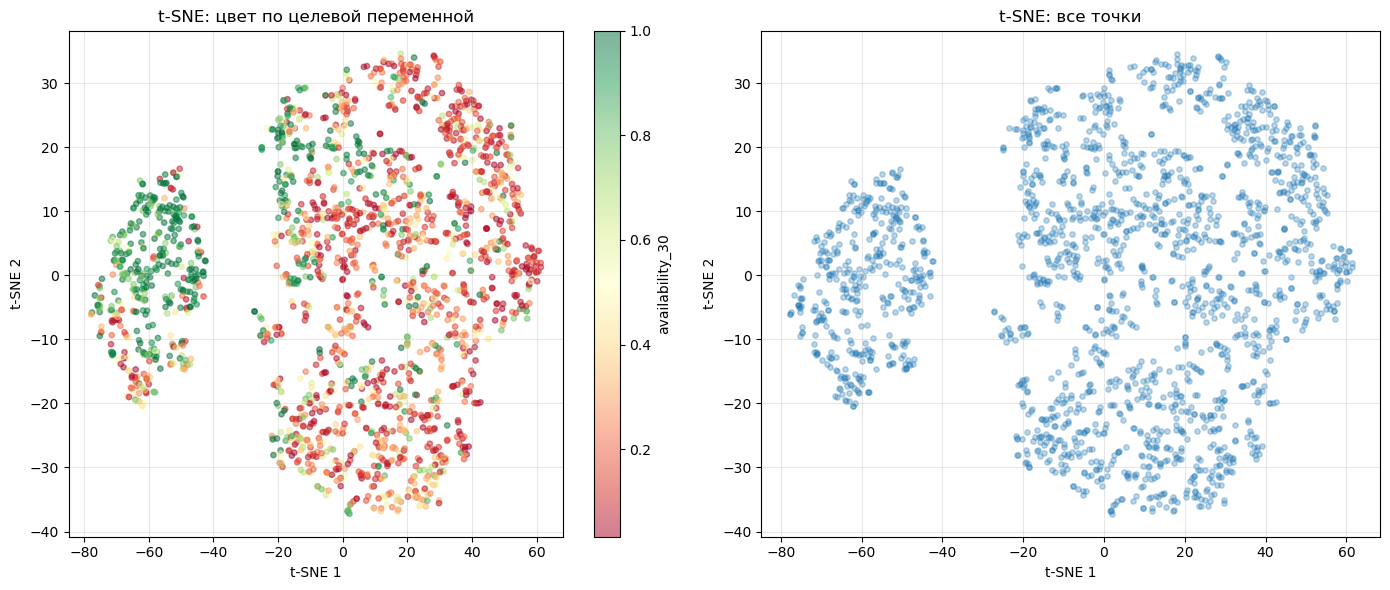


Trustworthiness: 0.9953


In [19]:
from sklearn.manifold import TSNE
from sklearn.manifold import trustworthiness
target_col = 'availability_30'

y_tsne_target = df_sample[target_col].values
tsne_sample_size = min(2000, len(X_sample))
np.random.seed(100)
tsne_indices = np.random.choice(len(X_sample), tsne_sample_size, replace=False)
X_tsne_input = X_sample[tsne_indices]

if y_tsne_target is not None:
    y_tsne_target = y_tsne_target[tsne_indices]

tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000, learning_rate='auto')
X_tsne = tsne.fit_transform(X_tsne_input)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
if y_tsne_target is not None:
    scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], 
                          c=y_tsne_target, cmap='RdYlGn', alpha=0.5, s=15)
    plt.colorbar(scatter, label=target_col)
else:
    plt.scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.5, s=15)
plt.title('t-SNE: цвет по целевой переменной' if y_tsne_target is not None else 't-SNE')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.3, s=15)
plt.title('t-SNE: все точки')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

trust = trustworthiness(X_tsne_input, X_tsne, n_neighbors=5)
print(f"\nTrustworthiness: {trust:.4f}")

Как мы можем заметить, два скопления объектов здесь можно выделить, но значения целевой переменной везде разные. Попробуем взять другие признаки из наших имеющихся воспользовавшись моделью случайного леса для создания кластеров. Модель Random Forest выделяет признаки на основе решения каждого из деревьев, которое они принимают на основе того, насколько уменьшается дисперсия после разделения по конкретному признаку.

Всего признаков: 37
Целевая переменная: availability_30

Качество модели Random Forest:
  MAE: 0.1772
  R²: 0.5409

Топ 20 признаков по версии модели случайного леса:
number_of_reviews_ltm                    0.533863
host_acceptance_rate                     0.085097
host_response_rate                       0.047098
number_of_reviews_l30d                   0.028829
minimum_nights_avg_ntm                   0.027273
calculated_host_listings_count_entire_homes 0.018285
calculated_host_listings_count           0.018114
longitude                                0.017987
host_age_on_platform                     0.017193
amenities_count                          0.015495
latitude                                 0.015331
reviews_per_month                        0.013441
host_total_listings_count                0.013068
accommodates                             0.011632
host_listings_count                      0.011488
minimum_minimum_nights                   0.011351
maximum_minimum_nights        

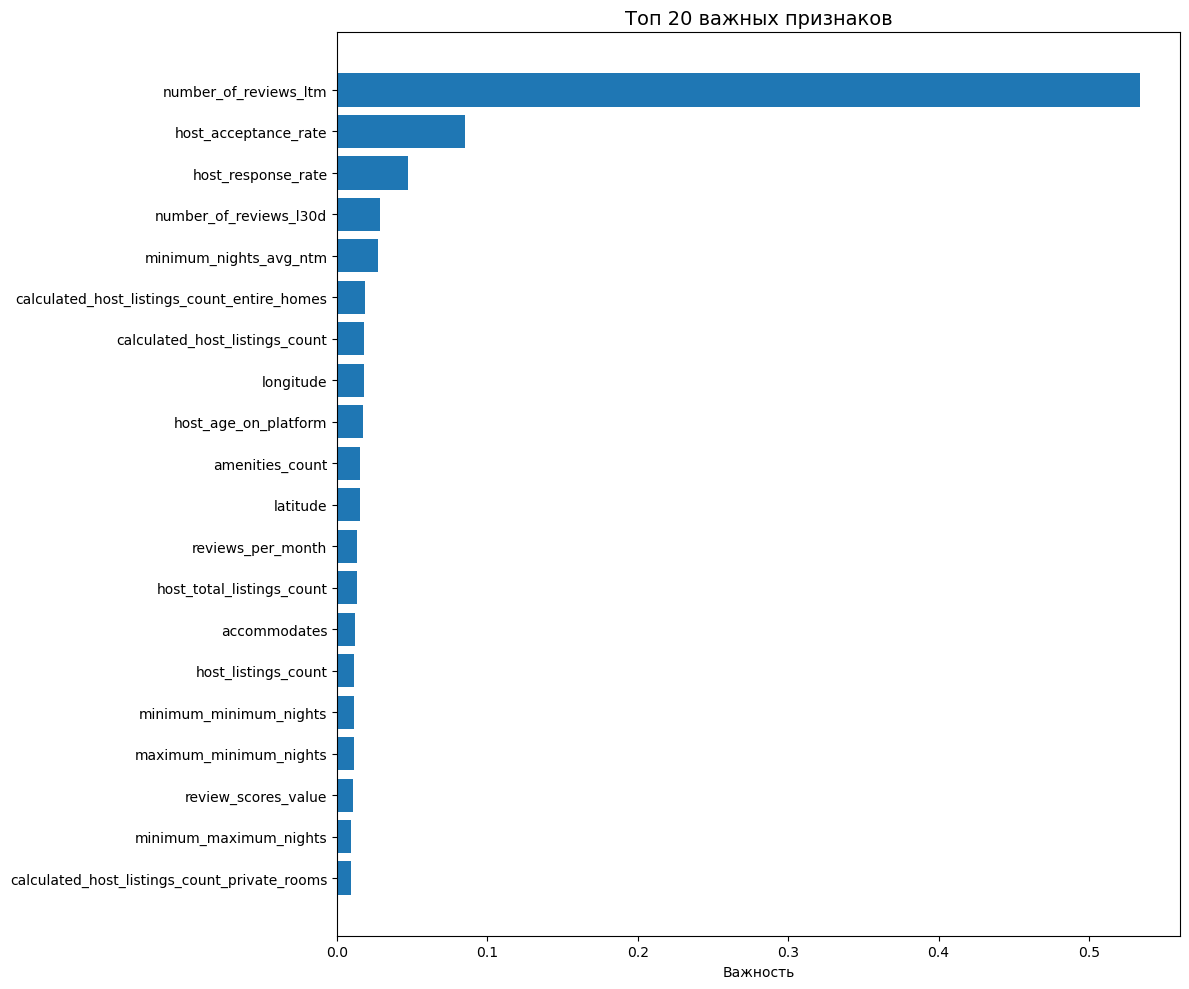

In [20]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

target = 'availability_30'

# все числовые признаки
exclude_cols = [target, 'cluster', 'segment']
features = [col for col in df.columns 
            if col not in exclude_cols 
            and df[col].dtype in ['int64', 'float64']]

print(f"Всего признаков: {len(features)}")
print(f"Целевая переменная: {target}")

X = df[features].fillna(0)
y = df[target].fillna(0)

# обучение леса
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# оценка качества
y_pred = rf.predict(X_test)
from sklearn.metrics import mean_absolute_error, r2_score

print(f"\nКачество модели Random Forest:")
print(f"  MAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"  R²: {r2_score(y_test, y_pred):.4f}")

# получаем важность каждого признака
importance_rf = pd.DataFrame({
    'feature': features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nТоп 20 признаков по версии модели случайного леса:")
for i, row in importance_rf.head(20).iterrows():
    print(f"{row['feature']:<40} {row['importance']:.6f}")


plt.figure(figsize=(12, 10))
plt.barh(importance_rf.head(20)['feature'], importance_rf.head(20)['importance'])
plt.xlabel('Важность')
plt.title('Топ 20 важных признаков', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


Посчитаем кумулятивную важность признаков для того чтобы понять, сколько признаков можно отобрать для нашей новой модели.

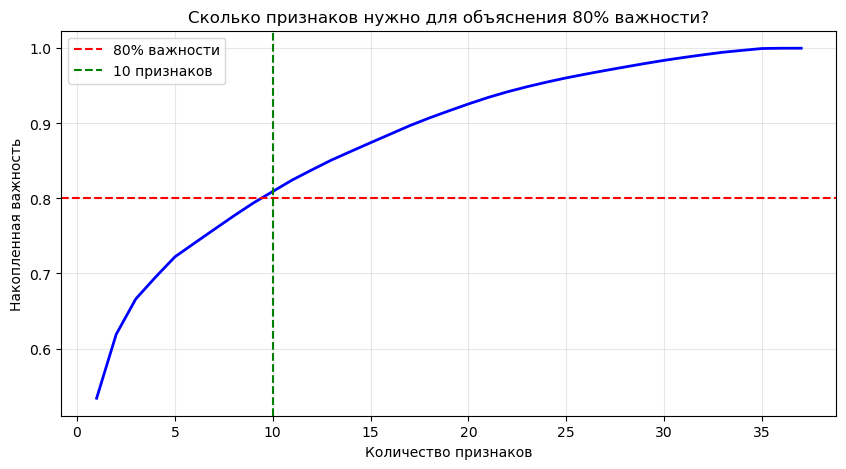


Для 80% важности нужно 10 признаков


In [21]:
cumsum_importance = importance_rf['importance'].cumsum()
n_features_80 = (cumsum_importance <= 0.8).sum() + 1

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumsum_importance)+1), cumsum_importance, 'b-', linewidth=2)
plt.axhline(y=0.8, color='r', linestyle='--', label='80% важности')
plt.axvline(x=n_features_80, color='g', linestyle='--', label=f'{n_features_80} признаков')
plt.xlabel('Количество признаков')
plt.ylabel('Накопленная важность')
plt.title('Сколько признаков нужно для объяснения 80% важности?')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nДля 80% важности нужно {n_features_80} признаков")

Попробуем оценить стабильность работы нашей модели случайного леса и посмотрим на результаты её работы с разными random state


Топ-10 признаков со стандартным отклонением:
number_of_reviews_ltm                    важность=0.5351 (±0.0013)
host_acceptance_rate                     важность=0.0840 (±0.0029)
host_response_rate                       важность=0.0476 (±0.0027)
number_of_reviews_l30d                   важность=0.0285 (±0.0003)
minimum_nights_avg_ntm                   важность=0.0278 (±0.0006)
calculated_host_listings_count           важность=0.0186 (±0.0008)
calculated_host_listings_count_entire_homes важность=0.0183 (±0.0003)
longitude                                важность=0.0180 (±0.0003)
host_age_on_platform                     важность=0.0170 (±0.0004)
latitude                                 важность=0.0156 (±0.0002)


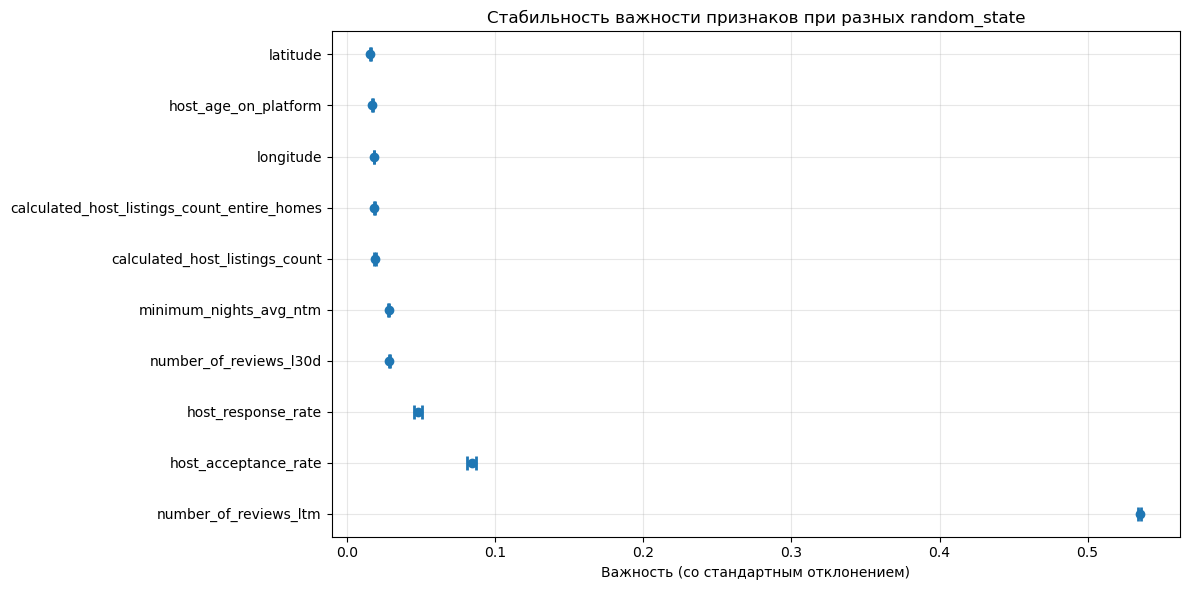

In [22]:
importance_stable = []
seeds = [42, 123, 456, 789]

for seed in seeds:
    rf_temp = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=seed, n_jobs=-1)
    rf_temp.fit(X_train, y_train)
    
    imp_temp = pd.DataFrame({
        'feature': features,
        f'importance_seed_{seed}': rf_temp.feature_importances_
    })
    importance_stable.append(imp_temp)

# объединяем результаты
from functools import reduce
importance_all = reduce(lambda left, right: pd.merge(left, right, on='feature'), importance_stable)
importance_all['mean_importance'] = importance_all.iloc[:, 1:].mean(axis=1)
importance_all['std_importance'] = importance_all.iloc[:, 1:].std(axis=1)
importance_all = importance_all.sort_values('mean_importance', ascending=False)

print("\nТоп-10 признаков со стандартным отклонением:")
for i, row in importance_all.head(10).iterrows():
    print(f"{row['feature']:<40} "
          f"важность={row['mean_importance']:.4f} "
          f"(±{row['std_importance']:.4f})")

top_10_stable = importance_all.head(10)

plt.figure(figsize=(12, 6))
plt.errorbar(top_10_stable['mean_importance'], 
             range(len(top_10_stable)), 
             xerr=top_10_stable['std_importance'],
             fmt='o', capsize=5, capthick=2)
plt.yticks(range(len(top_10_stable)), top_10_stable['feature'])
plt.xlabel('Важность (со стандартным отклонением)')
plt.title('Стабильность важности признаков при разных random_state')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Серьёзных отклонений у признаков нет, поэтому мы можем доверять модели. Теперь возьмём самые важные 10 признаков для нашей новой модели:


Проверка пропусков:
host_total_listings_count    5
host_listings_count          5
dtype: int64
host_total_listings_count: заполнено 0 пропусков
host_listings_count: заполнено 0 пропусков
Сделана выборка: 3000 объектов

Копенетическая корреляция: 0.7946


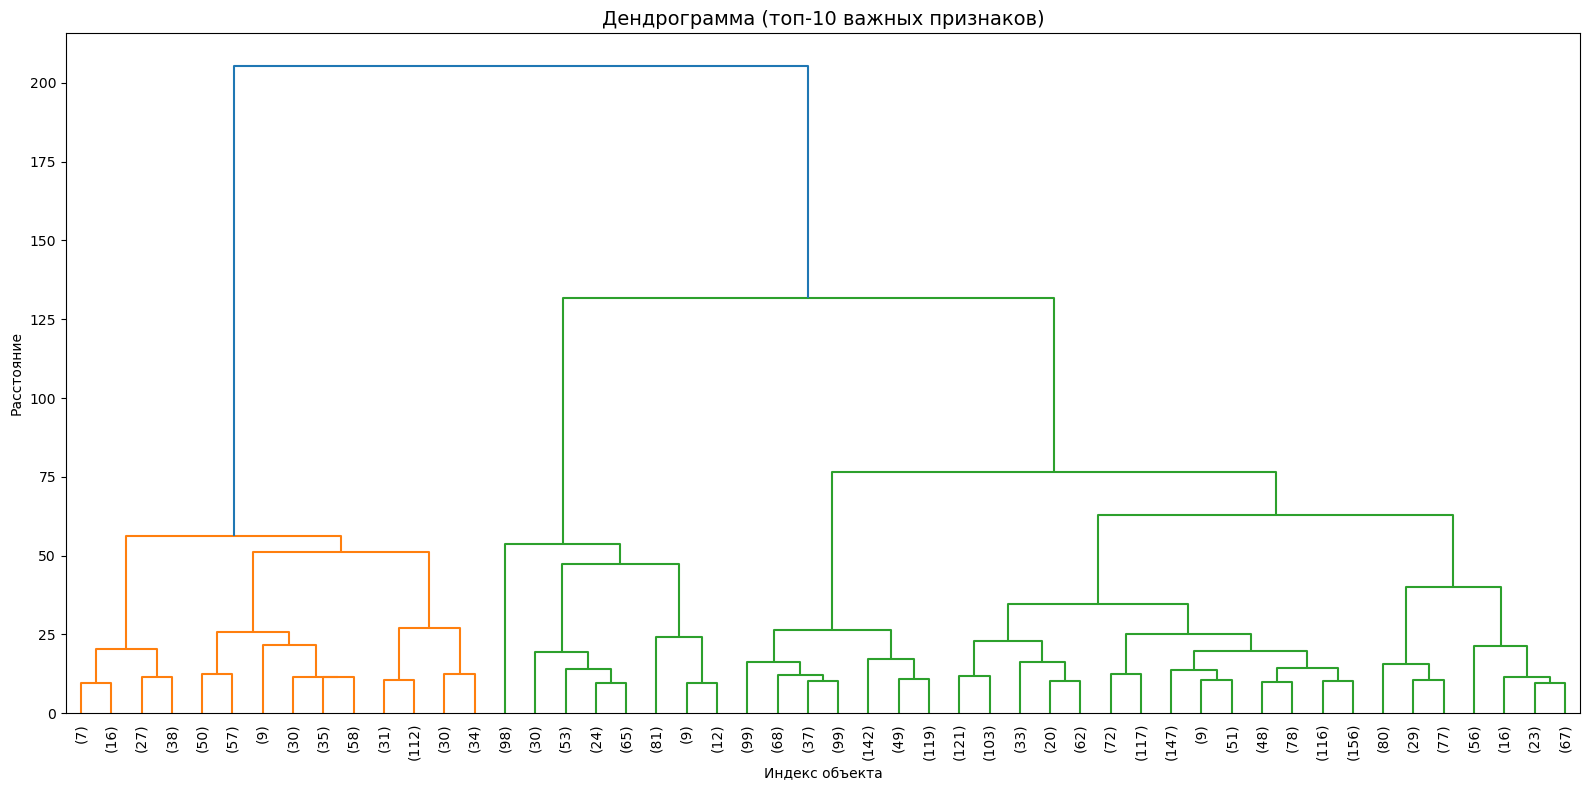

Silhoette score для разных K
k=2: Silhouette = 0.4753
k=3: Silhouette = 0.4377
k=4: Silhouette = 0.2524
k=5: Silhouette = 0.2522
k=6: Silhouette = 0.2545
k=7: Silhouette = 0.2685
k=8: Silhouette = 0.2668
k=9: Silhouette = 0.2815
k=10: Silhouette = 0.2801


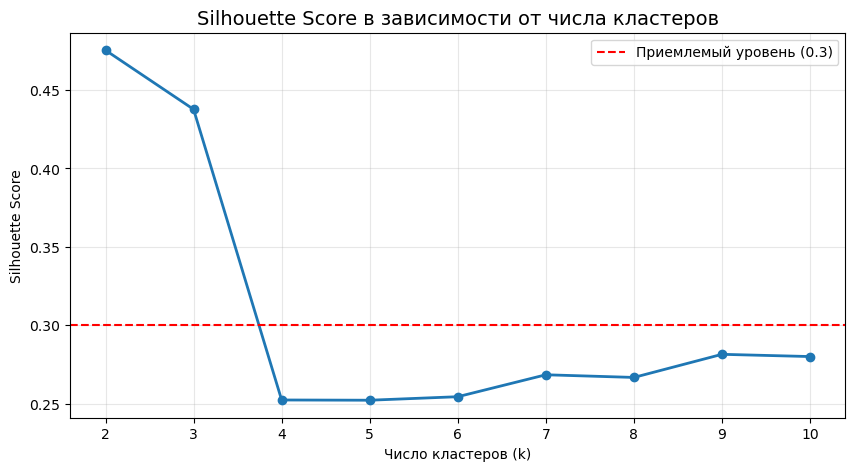


 Оптимальное число кластеров по Silhouette: 2 (score=0.4753)


In [23]:
top_10_features = importance_rf.head(17)['feature'].tolist()
df_top = df[top_10_features].copy()


print("\nПроверка пропусков:")
print(df_top.isnull().sum()[df_top.isnull().sum() > 0])

# заполняем оставшиеся пропуски (если есть)
for col in df_top.columns:
    if df_top[col].isna().any():
        df_top[col] = df_top[col].fillna(df_top[col].median())
        print(f"{col}: заполнено {df_top[col].isna().sum()} пропусков")


scaler = FunctionTransformer(np.log1p, validate=True)
X_scaled = scaler.fit_transform(df_top)


sample_size = min(3000, len(X_scaled))
np.random.seed(42)
indices = np.random.choice(len(X_scaled), sample_size, replace=False)
X_sample = X_scaled[indices]
df_sample = df_top.iloc[indices].copy()

print(f"Сделана выборка: {X_sample.shape[0]} объектов")

Z = linkage(X_sample, method='ward', metric='euclidean')

# коэффициент копенетической корреляции
c, coph_dists = cophenet(Z, pdist(X_sample))
print(f"\nКопенетическая корреляция: {c:.4f}")

plt.figure(figsize=(16, 8))
dendrogram(Z, truncate_mode='lastp', p=50, leaf_rotation=90., leaf_font_size=10)
plt.title('Дендрограмма (топ-10 важных признаков)', fontsize=14)
plt.xlabel('Индекс объекта')
plt.ylabel('Расстояние')
plt.tight_layout()
plt.show()

print("Silhoette score для разных K")

sil_scores = []
for k in range(2, 11):
    labels = fcluster(Z, t=k, criterion='maxclust')
    if len(set(labels)) > 1:
        score = silhouette_score(X_sample, labels)
        sil_scores.append(score)
        print(f"k={k}: Silhouette = {score:.4f}")

# График silhouette
plt.figure(figsize=(10, 5))
plt.plot(range(2, 11), sil_scores, marker='o', linewidth=2)
plt.title('Silhouette Score в зависимости от числа кластеров', fontsize=14)
plt.xlabel('Число кластеров (k)')
plt.ylabel('Silhouette Score')
plt.grid(True, alpha=0.3)
plt.axhline(y=0.3, color='r', linestyle='--', label='Приемлемый уровень (0.3)')
plt.legend()
plt.show()

best_k = range(2, 11)[np.argmax(sil_scores)]
print(f"\n Оптимальное число кластеров по Silhouette: {best_k} (score={max(sil_scores):.4f})")

Мы можем заметить что наше качество модели по Silhouette Score немного улучшилось. Теперь сделаем визуализацию и раскрасим по цвету кластеров для нашего наилучшего значения k=2.

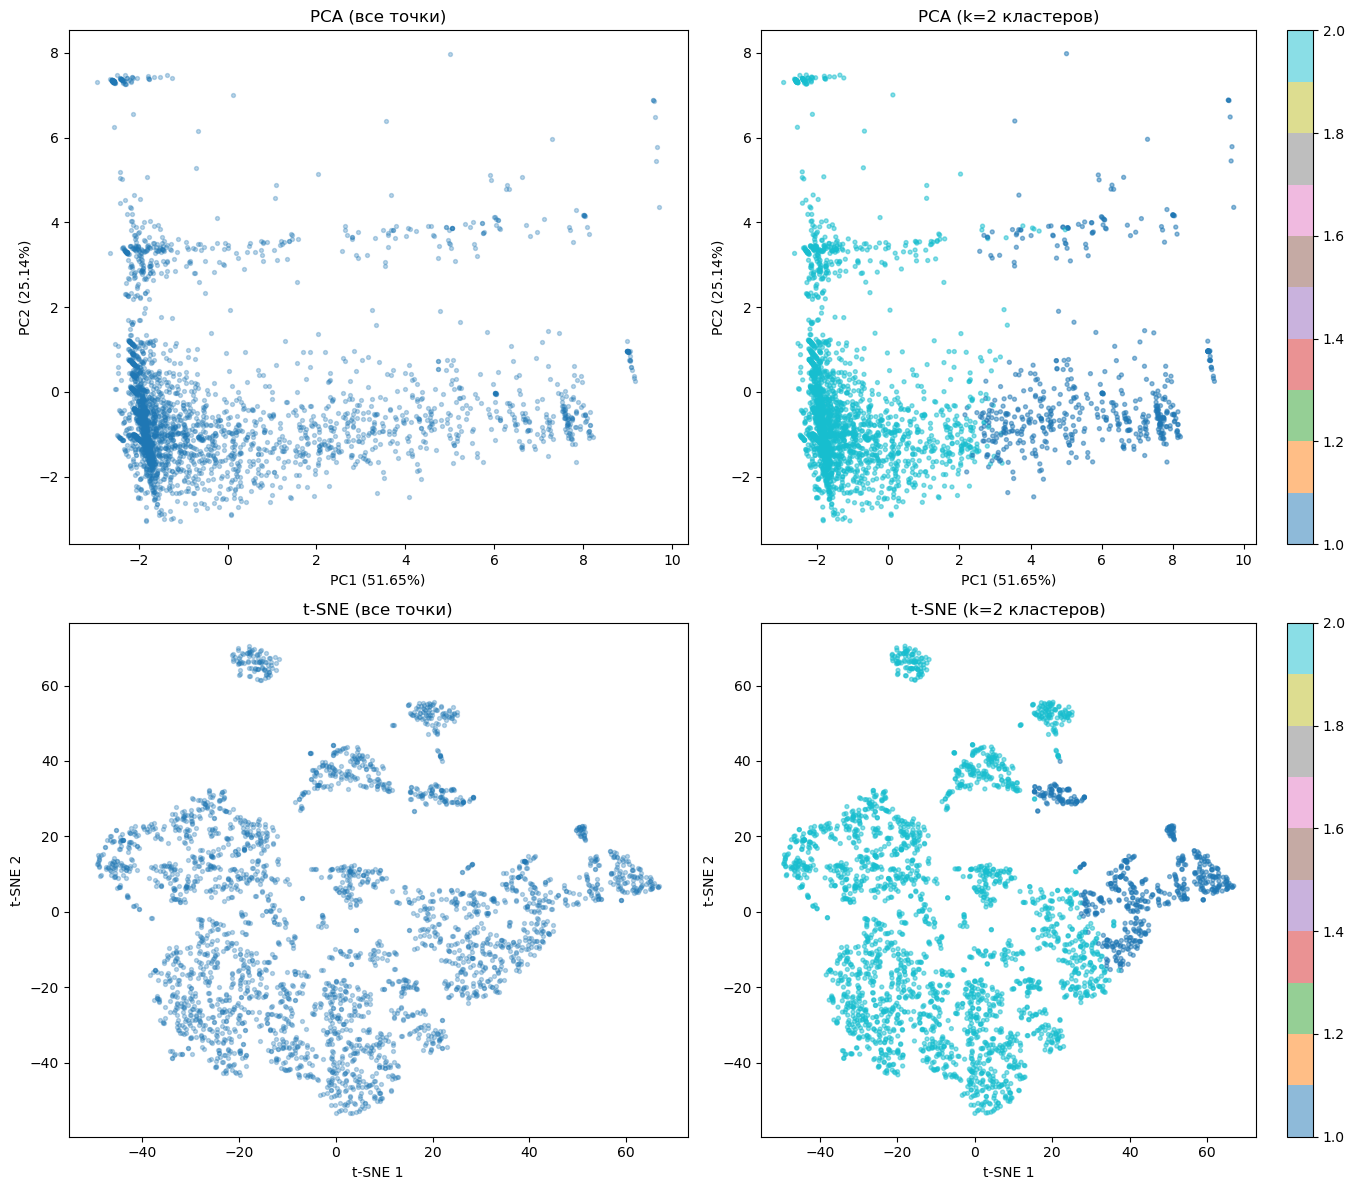

In [24]:
# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sample)

# t-SNE 
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_sample)

# берём оптимальные метки кластеров
optimal_labels = fcluster(Z, t=best_k, criterion='maxclust')

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# PCA (все точки)
axes[0, 0].scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.3, s=8)
axes[0, 0].set_title(f'PCA (все точки)')
axes[0, 0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
axes[0, 0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')

# PCA (цвет по кластерам)
scatter = axes[0, 1].scatter(X_pca[:, 0], X_pca[:, 1], c=optimal_labels, cmap='tab10', alpha=0.5, s=8)
axes[0, 1].set_title(f'PCA (k={best_k} кластеров)')
axes[0, 1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
axes[0, 1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.colorbar(scatter, ax=axes[0, 1])

# t-SNE (все точки)
axes[1, 0].scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.3, s=8)
axes[1, 0].set_title(f't-SNE (все точки)')
axes[1, 0].set_xlabel('t-SNE 1')
axes[1, 0].set_ylabel('t-SNE 2')

# t-SNE (цвет по кластерам)
scatter = axes[1, 1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=optimal_labels, cmap='tab10', alpha=0.5, s=8)
axes[1, 1].set_title(f't-SNE (k={best_k} кластеров)')
axes[1, 1].set_xlabel('t-SNE 1')
axes[1, 1].set_ylabel('t-SNE 2')
plt.colorbar(scatter, ax=axes[1, 1])

plt.tight_layout()
plt.show()

Посмотрим какими признаками отличаются наши кластеры, чтобы попытаться понять смысл их деления:

In [25]:
# добавляем метки кластеров
df_sample['cluster'] = optimal_labels

# профили кластеров (средние значения)
cluster_profiles = df_sample.groupby('cluster').mean()
cluster_profiles

,number_of_reviews_ltm,host_acceptance_rate,host_response_rate,number_of_reviews_l30d,minimum_nights_avg_ntm,calculated_host_listings_count_entire_homes,calculated_host_listings_count,longitude,host_age_on_platform,amenities_count,latitude,reviews_per_month,host_total_listings_count,accommodates,host_listings_count,minimum_minimum_nights,maximum_minimum_nights
cluster,,,,,,,,,,,,,,,,,
1,12.076779,0.928146,0.938202,1.007491,9.127341,112.389513,116.874532,2.336282,6.043348,32.419476,48.862839,1.398689,240.052434,4.264045,185.767790,7.629213,12.728464
2,10.258719,0.633358,0.689347,0.641525,22.878102,1.914842,2.466748,2.341222,7.556659,27.351987,48.863831,1.114355,4.242092,3.181671,3.129359,17.908354,33.333333


In [26]:
# находим признаки, которые лучше всего разделяют кластеры
feature_variance = cluster_profiles.var().sort_values(ascending=False)
feature_variance.head(5)

host_total_listings_count                      27803.258697
host_listings_count                            16678.398235
calculated_host_listings_count                  6544.570527
calculated_host_listings_count_entire_homes     6102.326495
maximum_minimum_nights                           212.280311
dtype: float64

In [27]:
df_sample['cluster'].value_counts().sort_index()

cluster
1     534
2    2466
Name: count, dtype: int64

In [28]:
if 'cluster' in cluster_profiles.columns:
    cluster_profiles = cluster_profiles.drop(columns=['cluster'])

cluster_sizes = df_sample['cluster'].value_counts().sort_index()
print("\nРазмер кластеров:")
print(cluster_sizes)

print("Отличительные признаки каждого кластера (отклонения от среднего)")

# рассчитываем отклонения в стандартных отклонениях
cluster_profiles_norm = (cluster_profiles - cluster_profiles.mean()) / cluster_profiles.std()

# для каждого кластера выводим топ-3 самых сильных отклонения
for cluster_id in cluster_profiles_norm.index:
    size = cluster_sizes[cluster_id]
    top_features = cluster_profiles_norm.loc[cluster_id].abs().sort_values(ascending=False).head(3)
    
    desc = f"Кластер {cluster_id} (n={size}): "
    for feat, score in top_features.items():
        diffr = "больше" if cluster_profiles_norm.loc[cluster_id, feat] > 0 else "меньше"
        desc += f"{feat} {diffr} на {abs(score):.2f} стандартных отклонения, "
    print(desc)


Размер кластеров:
cluster
1     534
2    2466
Name: count, dtype: int64
Отличительные признаки каждого кластера (отклонения от среднего)
Кластер 1 (n=534): minimum_nights_avg_ntm меньше на 0.71 стандартных отклонения, accommodates больше на 0.71 стандартных отклонения, host_age_on_platform меньше на 0.71 стандартных отклонения, 
Кластер 2 (n=2466): number_of_reviews_ltm меньше на 0.71 стандартных отклонения, reviews_per_month меньше на 0.71 стандартных отклонения, amenities_count меньше на 0.71 стандартных отклонения, 


Какие можно сделать выводы по этой кластеризации?
- Кластер 1 - многоместные объекты, сдающиеся владельцами с небольшим опытом на платформе
- Кластер 2 - все остальные объекты

Теперь же попробуем воспользоваться моделью DBSCAN (Density-Based Spatial Clustering of Applications with Noise). Она хорошо подходит для многомерных данных и способен найти не-шарообразные кластеры. Её основными параметрами являются eps - радиус поиска соседей; и min_samples - минимальное количество соседей чтобы образовать кластер. В нём кластеры образуются только когда обхекты имеют ярко выраженные аномальные черты, поэтому большинство объектов попадёт в шум, так как для модели они не имеют значительных различий. Эта модель очень чувствительна к выбросам, поэтому тут также будем использовать FunctionTransformer и логарифмическую функцию

In [29]:
from sklearn.cluster import DBSCAN

# исключаем служебные колонки
exclude_cols = ['cluster', 'segment']

X = df_top.copy()

# заполняем пропуски (на всякий случай)
for col in X.columns:
    if X[col].isna().any():
        X[col] = X[col].fillna(X[col].median())
        print(f"{col}: заполнено пропусков")

scaler = FunctionTransformer(np.log1p, validate=True)
X_scaled = scaler.fit_transform(X)

sample_size = 10000
np.random.seed(42)
indices = np.random.choice(len(X_scaled), sample_size, replace=False)
X_sample = X_scaled[indices]
df_sample = df_top.iloc[indices].copy()

print("DBSCAN с разными параметрами")
eps_values = [0.5, 0.8, 1.0, 1.2, 1.5, 2.0]
min_samples_values = [5, 10, 20]

best_score = -1
best_params = None

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_sample)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()
        
        if n_clusters > 1:
            # считаем силуэт только для не-шумовых точек
            mask = labels != -1
            if mask.sum() > n_clusters and mask.sum() > 10:
                try:
                    score = silhouette_score(X_sample[mask], labels[mask])
                    print(f"eps={eps}, min_samples={min_samples}: кластеров={n_clusters}, шума={n_noise}, silhouette={score:.4f}")
                    
                    if score > best_score:
                        best_score = score
                        best_params = (eps, min_samples)
                except:
                    print(f"eps={eps}, min_samples={min_samples}: кластеров={n_clusters}, шума={n_noise}, silhouette не вычислен")
            else:
                print(f"eps={eps}, min_samples={min_samples}: кластеров={n_clusters}, шума={n_noise}, слишком мало точек для silhouette")
        else:
            print(f"eps={eps}, min_samples={min_samples}: всего {n_clusters} кластеров, шума={n_noise}")

print(f"Лучшие параметры: eps={best_params[0]}, min_samples={best_params[1]}")
print(f"Silhouette score: {best_score:.4f}")
    
# обучаем финальную модель с лучшими параметрами
dbscan_best = DBSCAN(eps=best_params[0], min_samples=best_params[1])
labels_best = dbscan_best.fit_predict(X_sample)
    
n_clusters = len(set(labels_best)) - (1 if -1 in labels_best else 0)
n_noise = (labels_best == -1).sum()
    
print(f"\nФинальный результат:")
print(f"  Кластеров: {n_clusters}")
print(f"  Шума: {n_noise} ({n_noise/len(labels_best)*100:.1f}%)")
    
# распределение по кластерам
unique, counts = np.unique(labels_best, return_counts=True)
for label, count in zip(unique, counts):
    if label == -1:
        print(f"    Шум: {count} объектов")
    else:
        print(f"    Кластер {label}: {count} объектов")

DBSCAN с разными параметрами
eps=0.5, min_samples=5: кластеров=81, шума=7611, silhouette=0.0741
eps=0.5, min_samples=10: кластеров=17, шума=8405, silhouette=0.2513
eps=0.5, min_samples=20: кластеров=11, шума=8994, silhouette=0.3877
eps=0.8, min_samples=5: кластеров=91, шума=3618, silhouette=-0.0579
eps=0.8, min_samples=10: кластеров=25, шума=4822, silhouette=0.1831
eps=0.8, min_samples=20: кластеров=12, шума=5737, silhouette=0.2692
eps=1.0, min_samples=5: кластеров=44, шума=1470, silhouette=-0.0334
eps=1.0, min_samples=10: кластеров=23, шума=2255, silhouette=-0.1290
eps=1.0, min_samples=20: кластеров=16, шума=3423, silhouette=0.2028
eps=1.2, min_samples=5: кластеров=21, шума=564, silhouette=-0.1440
eps=1.2, min_samples=10: кластеров=9, шума=868, silhouette=0.0690
eps=1.2, min_samples=20: кластеров=8, шума=1411, silhouette=0.3262
eps=1.5, min_samples=5: кластеров=13, шума=167, silhouette=-0.0689
eps=1.5, min_samples=10: кластеров=4, шума=267, silhouette=0.0338
eps=1.5, min_samples=20: к

In [30]:
df_sample['cluster_dbscan'] = labels_best
cluster_sizes = df_sample['cluster_dbscan'].value_counts().sort_index()

# только объекты в кластерах (без шума)
cluster_profiles2 = df_sample[df_sample['cluster_dbscan'] != -1].groupby('cluster_dbscan').mean()
cluster_profiles2

,number_of_reviews_ltm,host_acceptance_rate,host_response_rate,number_of_reviews_l30d,minimum_nights_avg_ntm,calculated_host_listings_count_entire_homes,calculated_host_listings_count,longitude,host_age_on_platform,amenities_count,latitude,reviews_per_month,host_total_listings_count,accommodates,host_listings_count,minimum_minimum_nights,maximum_minimum_nights
cluster_dbscan,,,,,,,,,,,,,,,,,
0,10.891099,0.678684,0.727523,0.715518,20.630529,18.760175,20.169796,2.340618,7.350074,28.15031,48.863557,1.175147,36.415812,3.410433,27.451233,16.607734,28.574241
1,0.062500,0.980000,0.870000,0.000000,50.006250,816.000000,816.000000,2.322568,5.778168,25.59375,48.863629,0.016563,888.000000,3.187500,853.000000,44.062500,254.625000


In [31]:
print("Отличительные признаки каждого кластера:")
    
# нормализуем профили
cluster_profiles_norm = (cluster_profiles2 - cluster_profiles2.mean()) / cluster_profiles2.std()
    
for cluster_id in cluster_profiles_norm.index:
    size = cluster_sizes.loc[cluster_id]
    top_features = cluster_profiles_norm.loc[cluster_id].abs().sort_values(ascending=False).head(3)
        
    desc = f"Кластер {cluster_id} (n={size}): "
    for feat, score in top_features.items():
        diffr = "больше" if cluster_profiles_norm.loc[cluster_id, feat] > 0 else "меньше"
        desc += f"{feat} {diffr} на {abs(score):.2f} стандартного отклонения, "
    print(desc)

Отличительные признаки каждого кластера:
Кластер 0 (n=9853): latitude меньше на 0.71 стандартного отклонения, host_response_rate меньше на 0.71 стандартного отклонения, host_acceptance_rate меньше на 0.71 стандартного отклонения, 
Кластер 1 (n=32): minimum_nights_avg_ntm больше на 0.71 стандартного отклонения, number_of_reviews_ltm меньше на 0.71 стандартного отклонения, number_of_reviews_l30d меньше на 0.71 стандартного отклонения, 


Визуализация кластеров и шума:

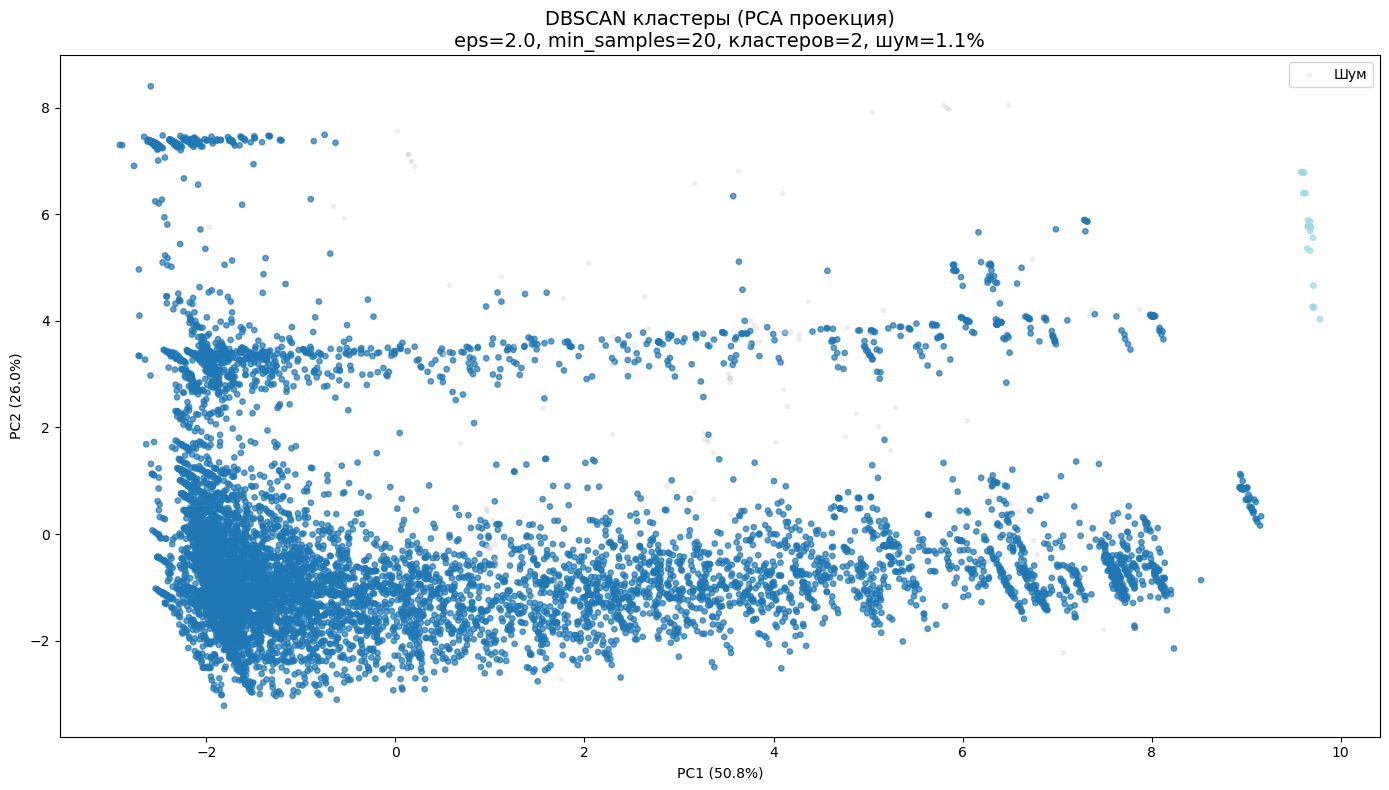

In [32]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sample)

plt.figure(figsize=(14, 8))

mask = labels != -1
if mask.sum() > 0:
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=labels[mask], cmap='tab20', alpha=0.7, s=15)
# шум
plt.scatter(X_pca[~mask, 0], X_pca[~mask, 1], c='lightgray', alpha=0.3, s=8, label='Шум')

plt.title(f'DBSCAN кластеры (PCA проекция)\neps={eps}, min_samples={min_samples}, кластеров={n_clusters}, шум={n_noise/len(labels)*100:.1f}%', fontsize=14)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.legend()
plt.tight_layout()
plt.show()

Как мы можем заметить, несмотря на высокий Silhouette score: 0.5250, выделить осмысленные кластеры не получилось, что может говорить нам о нехватке полезных данных в датасете.